# ABS Challenge System Analysis

The Automated Ball-Strike (ABS) Challenge System launched for the 2026 MLB regular season. Each team gets **two challenges per game** (refreshed each extra inning). Batters challenge called strikes; pitchers/catchers challenge called balls. Only correct challenges preserve a challenge token.

This notebook answers:
1. Which **batters** are most (and least) successful with challenges?
2. Which **catchers/pitchers** (defensive side) are most effective?
3. How do **teams** rank in challenge leverage — and total win-probability gained?
4. At what **counts** are players challenging, and does it pay off?
5. Who is **under-challenging** relative to model expectations (leaving value on the table)?

**Data sources**
- [Baseball Savant ABS Leaderboard](https://baseballsavant.mlb.com/leaderboard/abs-challenges) — aggregated player stats  
- [Baseball Savant Statcast Search](https://baseballsavant.mlb.com/statcast_search) via `pybaseball` — pitch-level events

## Setup

In [21]:
import warnings
warnings.filterwarnings('ignore')

import os
from datetime import date

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Local module
from abs_analysis import (
    fetch_abs_leaderboards_combined,
    fetch_statcast_abs_pitches,
    compute_team_challenge_stats,
    find_underchallengers,
    challenge_by_count,
    win_exp_by_challenge,
)

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
MLB_BLUE  = '#002D72'
MLB_RED   = '#D50032'
MLB_GRAY  = '#7B9EB2'
GOOD_COLOR = '#2ecc71'
BAD_COLOR  = '#e74c3c'

# ── Season parameters ───────────────────────────────────────────────────────
YEAR       = 2026
GAME_TYPE  = 'regular'   # 'regular' | 'spring' | 'postseason'

# Date range for pitch-level pull (update as season progresses)
PITCH_START = '2026-03-26'
PITCH_END   = '2026-03-30'

# ── Plot output directory (date-stamped for point-in-time snapshots) ────────
PLOT_DIR = f'plots/{date.today().isoformat()}'
os.makedirs(PLOT_DIR, exist_ok=True)

print(f'Setup complete. Plots will be saved to: {PLOT_DIR}')


## 1. Load ABS Leaderboard Data

In [22]:
batter_df, pitcher_df = fetch_abs_leaderboards_combined(
    year=YEAR,
    game_type=GAME_TYPE,
    min_challenges=0,
)

print(f'Batter leaderboard: {len(batter_df)} rows, columns: {list(batter_df.columns)}')
print(f'Pitcher/catcher leaderboard: {len(pitcher_df)} rows, columns: {list(pitcher_df.columns)}')

Batter leaderboard: 369 rows, columns: ['player_name', 'team_abbrev', 'level', 'parent_org', 'total_vs_expected', 'delta_win_exp', 'net_against', 'challenges', 'overturns', 'confirms', 'overturn_rate', 'expected_challenges', 'exp_chal_gained', 'exp_chal_lost', 'exp_rate_overturns', 'net_chal_gained', 'net_chal_lost', 'n_strikeouts_flip', 'n_walks_flip', 'challenge_rate', 'exp_rate_challenges_diff', 'opp_challenges', 'opp_overturns', 'n_confirms_against', 'opp_overturn_rate', 'exp_chal_against', 'exp_chal_gained_against', 'exp_chal_lost_against', 'exp_rate_overturns_against', 'net_chal_gained_against', 'net_chal_lost_against', 'n_strikeouts_flip_against', 'n_walks_flip_against', 'exp_rate_challenges_against', 'exp_rate_challenges_diff_against', 'challenge_type', 'year', 'game_type']
Pitcher/catcher leaderboard: 61 rows, columns: ['player_name', 'team_abbrev', 'level', 'parent_org', 'total_vs_expected', 'delta_win_exp', 'net_against', 'challenges', 'overturns', 'confirms', 'overturn_rate

In [23]:
# Quick peek
batter_df.head(5)

,player_name,team_abbrev,level,parent_org,total_vs_expected,delta_win_exp,net_against,challenges,overturns,confirms,...,exp_rate_overturns_against,net_chal_gained_against,net_chal_lost_against,n_strikeouts_flip_against,n_walks_flip_against,exp_rate_challenges_against,exp_rate_challenges_diff_against,challenge_type,year,game_type
0,Elly De La Cruz,CIN,MLB,CIN,1.274419,1.746365,0.471946,1,1,0,...,0.837753,0.345115,-0.126831,0.0,0.0,0.037225,0.010394,batter,2026,regular
1,Will Benson,CIN,MLB,CIN,1.597325,1.607824,0.010499,2,2,0,...,0.000000,0.000000,-0.010499,0.0,0.0,0.001312,-0.001312,batter,2026,regular
2,Mike Trout,LAA,MLB,LAA,0.551570,1.493863,0.942293,4,3,1,...,0.537930,0.590791,-0.351502,0.0,0.0,0.020019,0.006297,batter,2026,regular
3,Aaron Judge,NYY,MLB,NYY,1.447602,1.463774,0.016172,1,1,0,...,0.474515,-0.150555,-0.166726,0.0,0.0,0.012203,-0.012203,batter,2026,regular
4,Teoscar Hernandez,LAD,MLB,LAD,1.117913,1.281445,0.163533,2,2,0,...,0.000000,0.000000,-0.163533,0.0,0.0,0.010221,-0.010221,batter,2026,regular


## 2. Batter Challenge Performance

How often does a batter challenge a called strike, and how often does it get overturned?

In [24]:
# ── Helper: resolve the player name column (Savant uses different headers) ──
def player_col(df):
    for c in ('player_name', 'name', 'last_name, first_name'):
        if c in df.columns:
            return c
    return df.columns[0]

def team_col(df):
    for c in ('team_abbrev', 'team', 'team_id'):
        if c in df.columns:
            return c
    return None

P_COL = player_col(batter_df)
T_COL = team_col(batter_df)
print(f'Using player column: "{P_COL}"  |  team column: "{T_COL}"')

Using player column: "player_name"  |  team column: "team_abbrev"


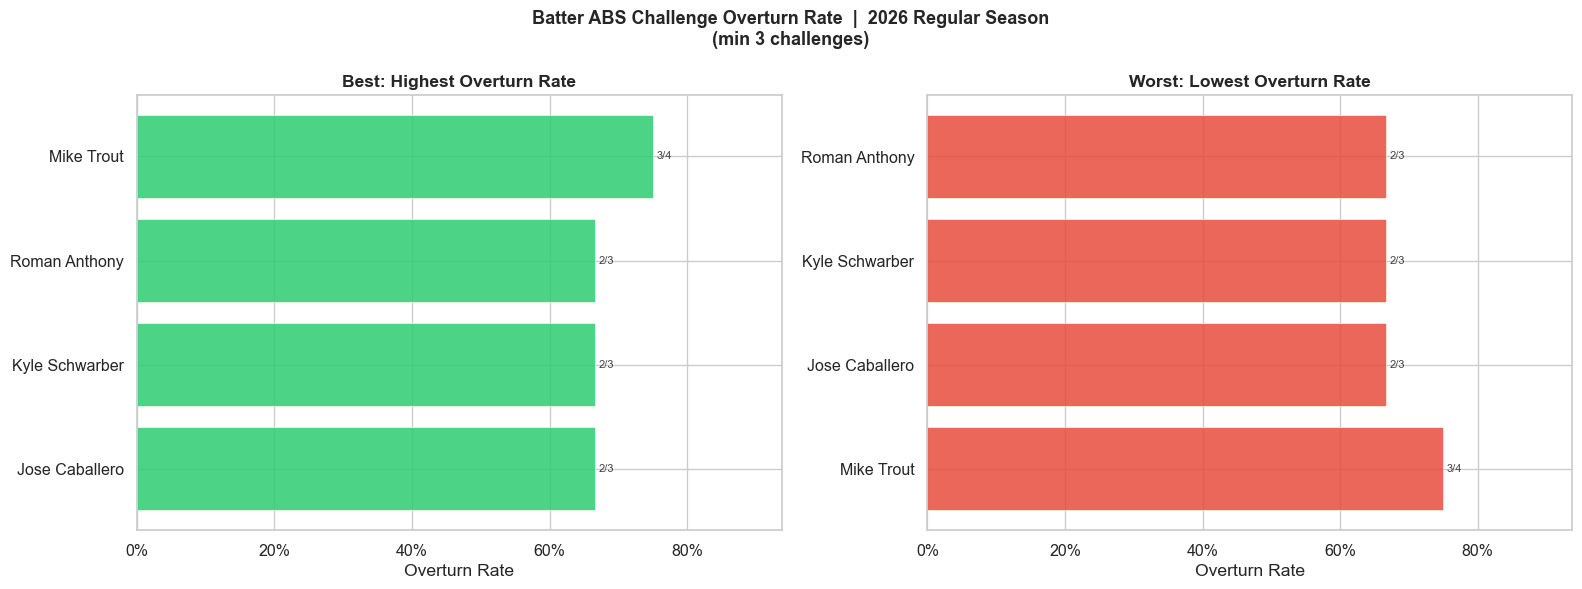

In [25]:
# Filter to batters with at least 3 challenges for meaningful sample
MIN_CHAL = 3
bat_filt = batter_df[batter_df['challenges'] >= MIN_CHAL].copy()

# Top 15 by overturn rate
top_bat = bat_filt.nlargest(15, 'overturn_rate')
bot_bat = bat_filt.nsmallest(15, 'overturn_rate')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle(
    f'Batter ABS Challenge Overturn Rate  |  {YEAR} {GAME_TYPE.title()} Season\n'
    f'(min {MIN_CHAL} challenges)',
    fontsize=13, fontweight='bold'
)

for ax, data, title, color in [
    (axes[0], top_bat, 'Best: Highest Overturn Rate', GOOD_COLOR),
    (axes[1], bot_bat, 'Worst: Lowest Overturn Rate', BAD_COLOR),
]:
    bars = ax.barh(
        data[P_COL], data['overturn_rate'],
        color=color, alpha=0.85, edgecolor='white', linewidth=0.5
    )
    # Annotate with challenge counts
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(
            bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{int(row['overturns'])}/{int(row['challenges'])}",
            va='center', fontsize=8, color='#444'
        )
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_xlabel('Overturn Rate')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlim(0, min(1.15, data['overturn_rate'].max() * 1.25))

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/abs_batter_overturn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Challenge Rate — how aggressively are batters challenging?
if 'challenge_rate' in bat_filt.columns:
    top_chal_rate = bat_filt.nlargest(20, 'challenge_rate')

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = [
        GOOD_COLOR if r >= 0.10 else (MLB_GRAY if r >= 0.05 else BAD_COLOR)
        for r in top_chal_rate['challenge_rate']
    ]
    ax.barh(
        top_chal_rate[P_COL], top_chal_rate['challenge_rate'],
        color=colors, alpha=0.85, edgecolor='white'
    )
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_xlabel('Challenge Rate (challenges / challengeable pitches)')
    ax.set_title(
        f'Batter Challenge Rate — Top 20  |  {YEAR} {GAME_TYPE.title()}\n'
        'Green ≥ 10% | Gray 5–10% | Red < 5%',
        fontweight='bold'
    )
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/abs_batter_challenge_rate.png', dpi=150, bbox_inches='tight')
    plt.show()

In [27]:
# Scatter: Challenge Rate vs Overturn Rate (efficiency vs aggressiveness)
if {'challenge_rate', 'overturn_rate', 'challenges'}.issubset(bat_filt.columns):
    fig, ax = plt.subplots(figsize=(10, 7))

    # Scale bubble size — ensure even 1-challenge batters are visible
    sizes = bat_filt['challenges'].clip(lower=1) * 40

    scatter = ax.scatter(
        bat_filt['challenge_rate'],
        bat_filt['overturn_rate'],
        s=sizes,
        c=bat_filt['challenges'],
        cmap='YlOrRd',
        alpha=0.75,
        edgecolors='gray',
        linewidths=0.4,
    )

    # Label top players by total overturns
    top_label = bat_filt.nlargest(10, 'overturns')
    for _, row in top_label.iterrows():
        ax.annotate(
            row[P_COL],
            (row['challenge_rate'], row['overturn_rate']),
            textcoords='offset points', xytext=(6, 3),
            fontsize=7.5, color=MLB_BLUE,
        )

    # Quadrant lines at medians
    med_cr = bat_filt['challenge_rate'].median()
    med_or = bat_filt['overturn_rate'].median()
    ax.axvline(med_cr, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(med_or, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

    # Quadrant labels positioned via axes transform so they stay in corners
    label_kw = dict(fontsize=8, transform=ax.transAxes, alpha=0.7)
    ax.text(0.02, 0.98, 'Passive, Good',  color=MLB_GRAY, va='top', ha='left',  **label_kw)
    ax.text(0.98, 0.98, 'Aggressive, Good', color=GOOD_COLOR, va='top', ha='right', **label_kw)
    ax.text(0.02, 0.02, 'Passive, Bad',   color=MLB_GRAY, va='bottom', ha='left',  **label_kw)
    ax.text(0.98, 0.02, 'Aggressive, Bad',  color=BAD_COLOR, va='bottom', ha='right', **label_kw)

    plt.colorbar(scatter, ax=ax, label='# of Challenges')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_xlabel('Challenge Rate')
    ax.set_ylabel('Overturn Rate')
    ax.set_title(
        f'Batter Challenge Efficiency  |  {YEAR} {GAME_TYPE.title()}\n'
        f'Bubble size = # of challenges  |  min {MIN_CHAL} challenges',
        fontweight='bold',
    )
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/abs_batter_efficiency_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()


## 3. Pitcher / Catcher (Defensive) Challenge Performance

On the defensive side, the pitcher or catcher can challenge a called ball. A successful challenge flips the call to a strike.

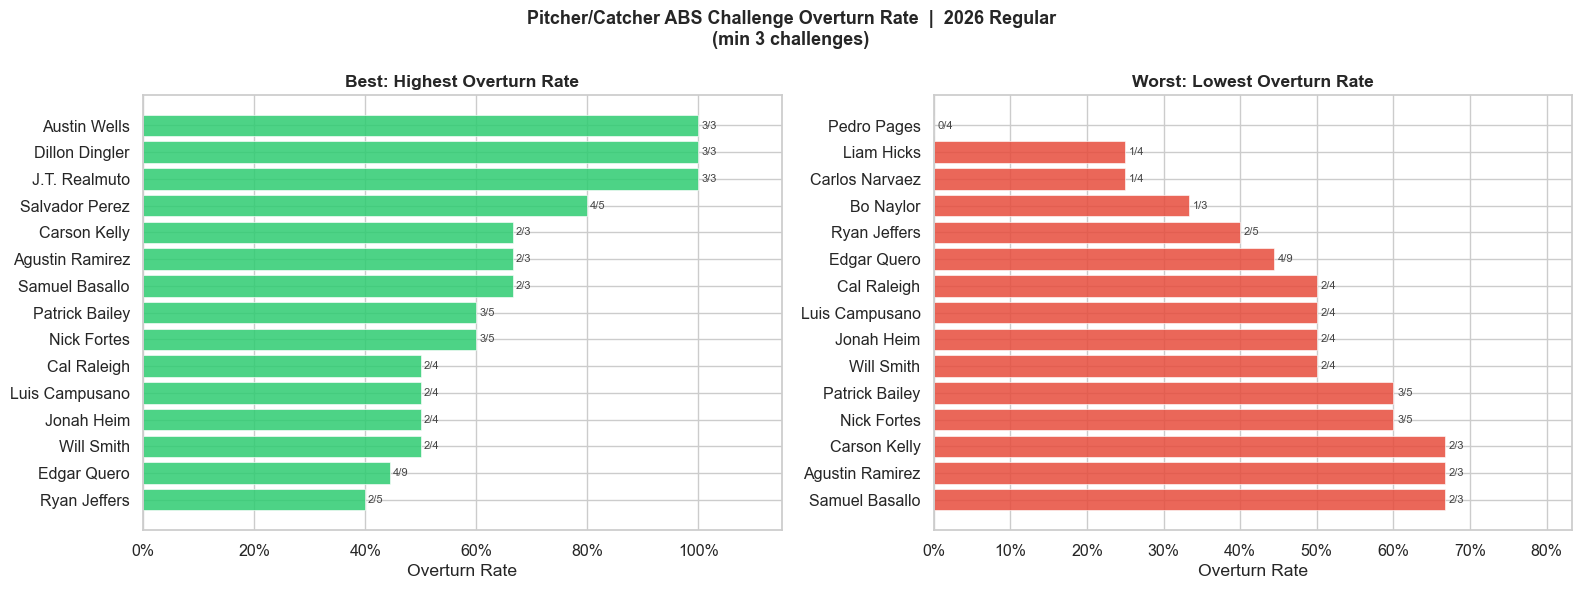

In [28]:
P_COL_DEF = player_col(pitcher_df)
T_COL_DEF = team_col(pitcher_df)

pit_filt = pitcher_df[pitcher_df['challenges'] >= MIN_CHAL].copy()

top_pit = pit_filt.nlargest(15, 'overturn_rate')
bot_pit = pit_filt.nsmallest(15, 'overturn_rate')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Pitcher/Catcher ABS Challenge Overturn Rate  |  {YEAR} {GAME_TYPE.title()}\n'
    f'(min {MIN_CHAL} challenges)',
    fontsize=13, fontweight='bold'
)

for ax, data, title, color in [
    (axes[0], top_pit, 'Best: Highest Overturn Rate', GOOD_COLOR),
    (axes[1], bot_pit, 'Worst: Lowest Overturn Rate', BAD_COLOR),
]:
    bars = ax.barh(
        data[P_COL_DEF], data['overturn_rate'],
        color=color, alpha=0.85, edgecolor='white', linewidth=0.5
    )
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(
            bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{int(row['overturns'])}/{int(row['challenges'])}",
            va='center', fontsize=8, color='#444'
        )
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_xlabel('Overturn Rate')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlim(0, min(1.15, data['overturn_rate'].max() * 1.25))

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/abs_pitcher_overturn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Team-Level Challenge Analysis

Which organizations are leveraging the system best — both offensively (batters) and defensively (pitchers/catchers)?

In [29]:
team_stats = compute_team_challenge_stats(batter_df, pitcher_df)
team_stats.head(10)

,team,bat_challenges,bat_overturns,bat_expected_challenges,bat_opp_challenges,bat_opp_overturns,bat_delta_win_exp,bat_overturn_rate,bat_challenge_rate,def_challenges,def_overturns,def_expected_challenges,def_opp_challenges,def_opp_overturns,def_delta_win_exp,def_overturn_rate,def_challenge_rate,total_delta_win_exp
19,NYY,8,7,5.910381,4.0,3.0,4.893139,0.944444,0.047259,3,3,4.025460,2.0,2.0,4.571225,1.000000,0.021527,9.464364
6,CIN,7,7,7.355645,5.0,3.0,6.225206,1.000000,0.072275,2,1,4.998609,4.0,2.0,0.975317,0.500000,0.017061,7.200523
12,KC,1,1,5.033876,5.0,2.0,2.488741,1.000000,0.063921,5,4,3.607833,4.0,0.0,2.294690,0.800000,0.018193,4.783430
20,PHI,5,2,4.914636,2.0,0.0,0.391551,0.222222,0.036069,3,3,4.490155,2.0,1.0,3.417334,1.000000,0.014735,3.808885
5,CHC,2,2,3.645779,3.0,2.0,2.743848,1.000000,0.031149,3,2,3.989925,3.0,1.0,0.870963,0.666667,0.017793,3.614811
3,BAL,4,3,4.346698,5.0,3.0,1.645709,0.750000,0.057571,5,4,6.380791,8.0,5.0,1.749389,0.833333,0.032073,3.395097
10,DET,4,1,5.311985,4.0,3.0,-1.079480,0.250000,0.048999,3,3,4.155224,2.0,1.0,3.835412,1.000000,0.015902,2.755931
24,SF,3,2,4.054727,4.0,3.0,0.780614,0.500000,0.050112,5,3,4.065182,4.0,3.0,1.829913,0.600000,0.019175,2.610527
2,AZ,1,1,4.542259,7.0,4.0,2.032509,1.000000,0.040490,2,2,4.929180,1.0,0.0,0.376863,1.000000,0.018951,2.409372
14,LAD,2,2,4.060145,3.0,2.0,2.287756,1.000000,0.044520,4,2,5.486320,2.0,2.0,-0.068631,0.500000,0.022094,2.219125


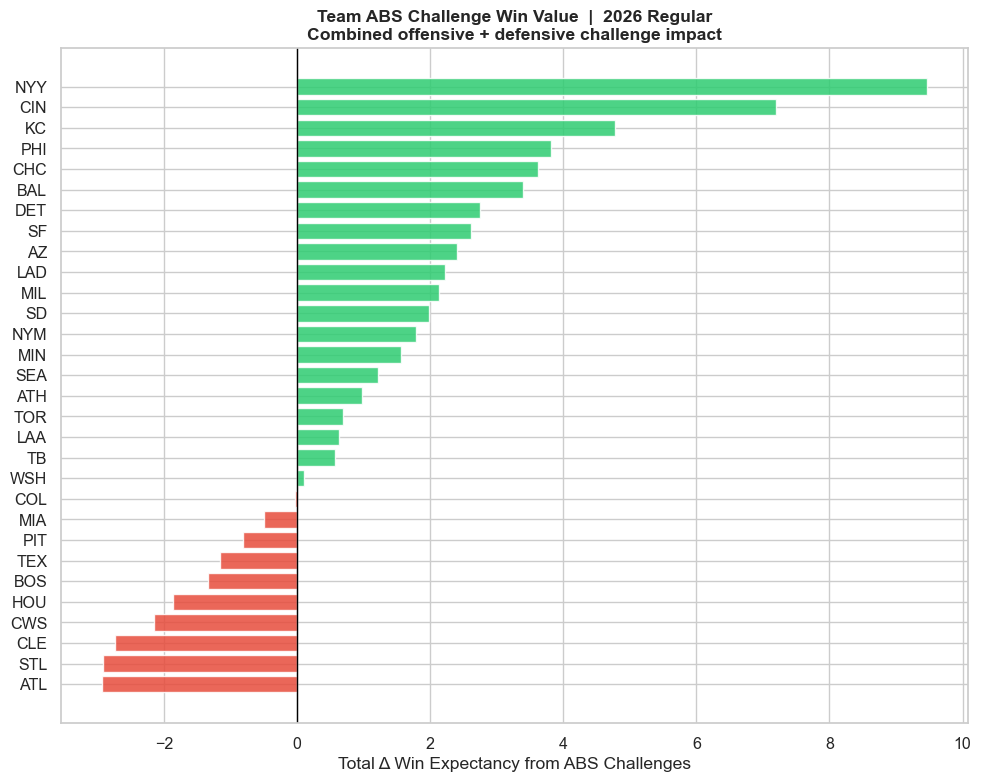

In [30]:
# Total win expectancy gained per team from challenges
if 'total_delta_win_exp' in team_stats.columns:
    fig, ax = plt.subplots(figsize=(10, 8))
    ts = team_stats.sort_values('total_delta_win_exp', ascending=True)
    colors = [GOOD_COLOR if v >= 0 else BAD_COLOR for v in ts['total_delta_win_exp']]
    ax.barh(ts['team'], ts['total_delta_win_exp'], color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('Total Δ Win Expectancy from ABS Challenges')
    ax.set_title(
        f'Team ABS Challenge Win Value  |  {YEAR} {GAME_TYPE.title()}\n'
        'Combined offensive + defensive challenge impact',
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/abs_team_win_exp.png', dpi=150, bbox_inches='tight')
    plt.show()

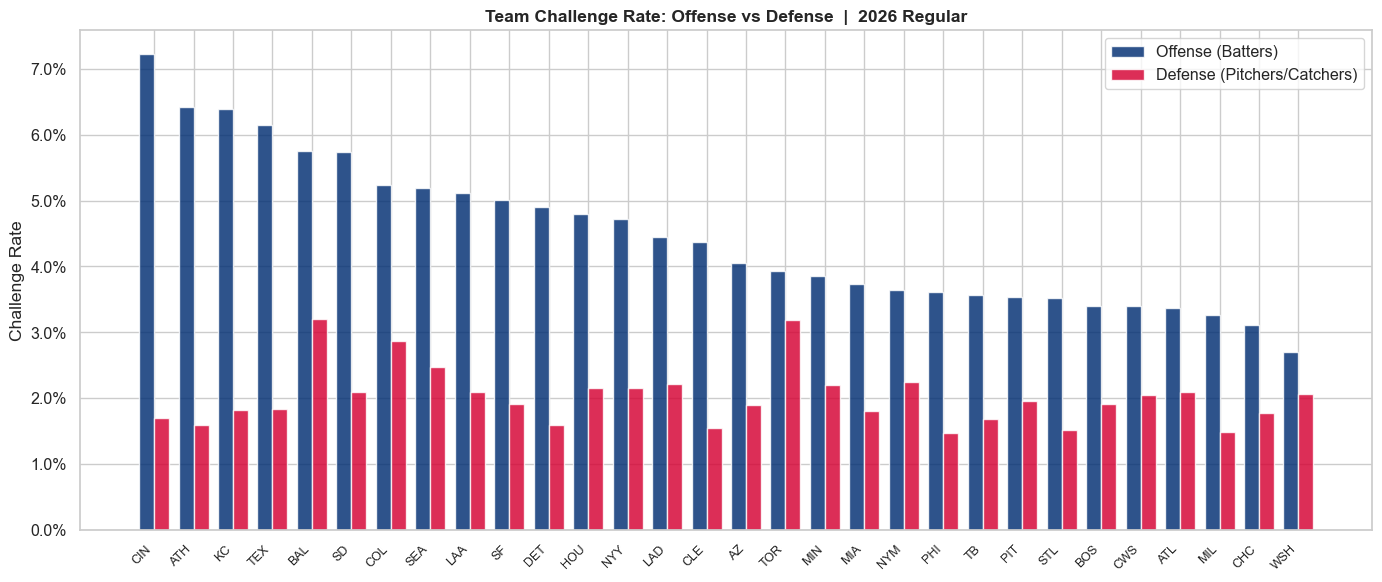

In [31]:
# Grouped bar: offensive vs defensive challenge rates by team
rate_cols = [c for c in ('bat_challenge_rate', 'def_challenge_rate') if c in team_stats.columns]
if len(rate_cols) == 2:
    ts_sorted = team_stats.sort_values('bat_challenge_rate', ascending=False)
    x = np.arange(len(ts_sorted))
    width = 0.38

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x - width/2, ts_sorted['bat_challenge_rate'], width, label='Offense (Batters)',
           color=MLB_BLUE, alpha=0.82)
    ax.bar(x + width/2, ts_sorted['def_challenge_rate'], width, label='Defense (Pitchers/Catchers)',
           color=MLB_RED, alpha=0.82)

    ax.set_xticks(x)
    ax.set_xticklabels(ts_sorted['team'], rotation=45, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_ylabel('Challenge Rate')
    ax.set_title(
        f'Team Challenge Rate: Offense vs Defense  |  {YEAR} {GAME_TYPE.title()}',
        fontweight='bold'
    )
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/abs_team_challenge_rate.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Team-Level Challenge Stats Table

In [32]:
display_cols = [c for c in [
    'team',
    'bat_challenges', 'bat_overturns', 'bat_overturn_rate', 'bat_challenge_rate',
    'def_challenges', 'def_overturns', 'def_overturn_rate', 'def_challenge_rate',
    'total_delta_win_exp',
] if c in team_stats.columns]

fmt = {}
for c in display_cols:
    if 'rate' in c:
        fmt[c] = '{:.1%}'
    elif 'delta' in c or 'win' in c:
        fmt[c] = '{:+.3f}'

team_stats[display_cols].sort_values('total_delta_win_exp', ascending=False).style.format(fmt)

,team,bat_challenges,bat_overturns,bat_overturn_rate,bat_challenge_rate,def_challenges,def_overturns,def_overturn_rate,def_challenge_rate,total_delta_win_exp
19,NYY,8,7,94.4%,4.7%,3,3,100.0%,2.2%,+9.464
6,CIN,7,7,100.0%,7.2%,2,1,50.0%,1.7%,+7.201
12,KC,1,1,100.0%,6.4%,5,4,80.0%,1.8%,+4.783
20,PHI,5,2,22.2%,3.6%,3,3,100.0%,1.5%,+3.809
5,CHC,2,2,100.0%,3.1%,3,2,66.7%,1.8%,+3.615
3,BAL,4,3,75.0%,5.8%,5,4,83.3%,3.2%,+3.395
10,DET,4,1,25.0%,4.9%,3,3,100.0%,1.6%,+2.756
24,SF,3,2,50.0%,5.0%,5,3,60.0%,1.9%,+2.611
2,AZ,1,1,100.0%,4.0%,2,2,100.0%,1.9%,+2.409
14,LAD,2,2,100.0%,4.5%,4,2,50.0%,2.2%,+2.219


## 6. Count-Specific Challenge Tendencies

Using pitch-level Statcast data to see *when* players are challenging — and whether those challenges succeed.

**Caveat:** ABS challenge events are identified by parsing the `des` (play description) narrative text for
`"challenged (pitch result)"`. If Baseball Savant changes this wording, some events could be missed.
Additionally, Statcast pitch-level data may lag behind or count differently than the aggregated
ABS leaderboard API — expect the pitch-level totals here to be lower than leaderboard totals,
especially early in the season.


In [33]:
all_pitches, challenge_pitches = fetch_statcast_abs_pitches(PITCH_START, PITCH_END)

print(f'Challenge pitches loaded: {len(challenge_pitches)}')
if not challenge_pitches.empty:
    print(f"  Overturned: {challenge_pitches['is_overturn'].sum()}  |  "
          f"Confirmed: {(~challenge_pitches['is_overturn']).sum()}")
    print(challenge_pitches['challenger'].value_counts())


In [34]:
count_stats = challenge_by_count(challenge_pitches)

if not count_stats.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'ABS Challenges by Ball-Strike Count  |  {PITCH_START} to {PITCH_END}',
        fontsize=13, fontweight='bold'
    )

    # Volume heatmap
    pivot_n = count_stats.pivot(index='balls', columns='strikes', values='n_challenges').fillna(0)
    sns.heatmap(
        pivot_n, ax=axes[0], annot=True, fmt='.0f',
        cmap='Blues', linewidths=0.5, cbar_kws={'label': '# Challenges'}
    )
    axes[0].set_title('Volume of Challenges', fontweight='bold')
    axes[0].set_xlabel('Strikes')
    axes[0].set_ylabel('Balls')

    # Overturn rate heatmap
    pivot_or = count_stats.pivot(index='balls', columns='strikes', values='overturn_rate').fillna(0)
    sns.heatmap(
        pivot_or, ax=axes[1], annot=True, fmt='.0%',
        cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.5,
        cbar_kws={'label': 'Overturn Rate'}
    )
    axes[1].set_title('Overturn Rate by Count', fontweight='bold')
    axes[1].set_xlabel('Strikes')
    axes[1].set_ylabel('Balls')

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/abs_challenge_by_count.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No pitch-level challenge data available for this date range.')

No pitch-level challenge data available for this date range.


## 7. Win-Probability Impact of Challenges

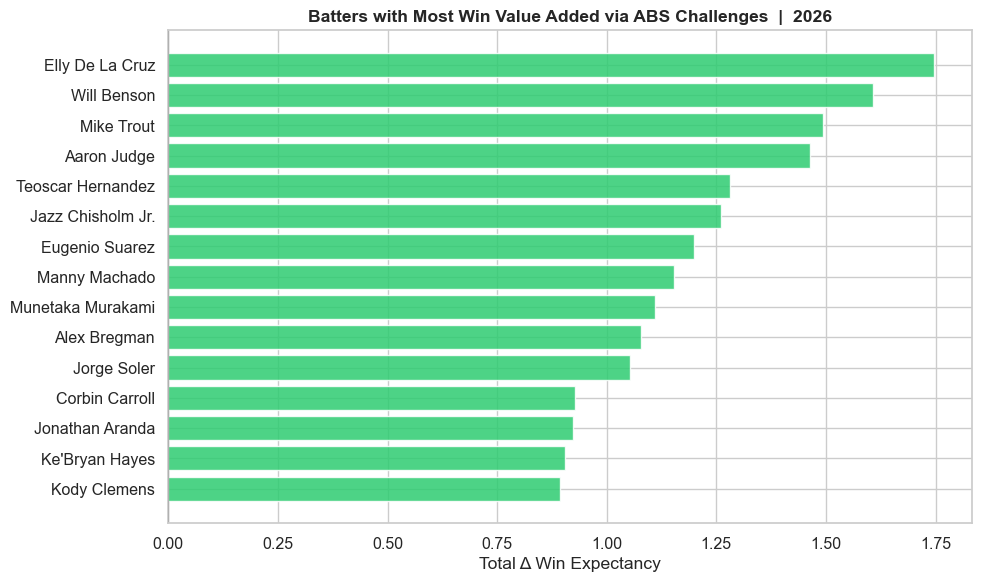

In [35]:
# Win expectancy from leaderboard (player level)
if 'delta_win_exp' in batter_df.columns:
    top_we_bat = batter_df.nlargest(15, 'delta_win_exp')

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [GOOD_COLOR if v >= 0 else BAD_COLOR for v in top_we_bat['delta_win_exp']]
    ax.barh(top_we_bat[P_COL], top_we_bat['delta_win_exp'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Total Δ Win Expectancy')
    ax.set_title(
        f'Batters with Most Win Value Added via ABS Challenges  |  {YEAR}',
        fontweight='bold'
    )
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/abs_batter_win_exp.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('delta_win_exp not available in leaderboard data.')

In [36]:
# Win expectancy from pitch-level data (by challenger type & outcome)
we_breakdown = win_exp_by_challenge(challenge_pitches)

if not we_breakdown.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    we_breakdown['label'] = (
        we_breakdown['challenger'] + '\n' +
        we_breakdown['is_overturn'].map({True: 'Overturned ✓', False: 'Upheld ✗'})
    )
    colors = [GOOD_COLOR if o else BAD_COLOR for o in we_breakdown['is_overturn']]
    ax.bar(we_breakdown['label'], we_breakdown['avg_delta_win_exp'],
           color=colors, alpha=0.85, width=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Avg Δ Win Expectancy per Pitch')
    ax.set_title(
        'Win Expectancy Impact: Challenge Outcome by Type',
        fontweight='bold'
    )
    for i, (_, row) in enumerate(we_breakdown.iterrows()):
        ax.text(i, row['avg_delta_win_exp'] + 0.001, f"n={int(row['n'])}",
                ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/abs_win_exp_by_type.png', dpi=150, bbox_inches='tight')
    plt.show()

  No challenge pitch data available for win expectancy breakdown.


## 8. Under-Challengers: Leaving Value on the Table

These players had the opportunity to challenge — and a model suggests they *should* have challenged — but didn't. They may be unfamiliar with the zone, overly conservative, or simply unaware of close calls.

In [37]:
underchal_bat = find_underchallengers(batter_df, min_opportunities=5, max_pct_of_expected=0.60)
underchal_pit = find_underchallengers(pitcher_df, min_opportunities=5, max_pct_of_expected=0.60)

print(f'Under-challenging batters: {len(underchal_bat)}')
print(f'Under-challenging pitchers/catchers: {len(underchal_pit)}')

Under-challenging batters: 0
Under-challenging pitchers/catchers: 1


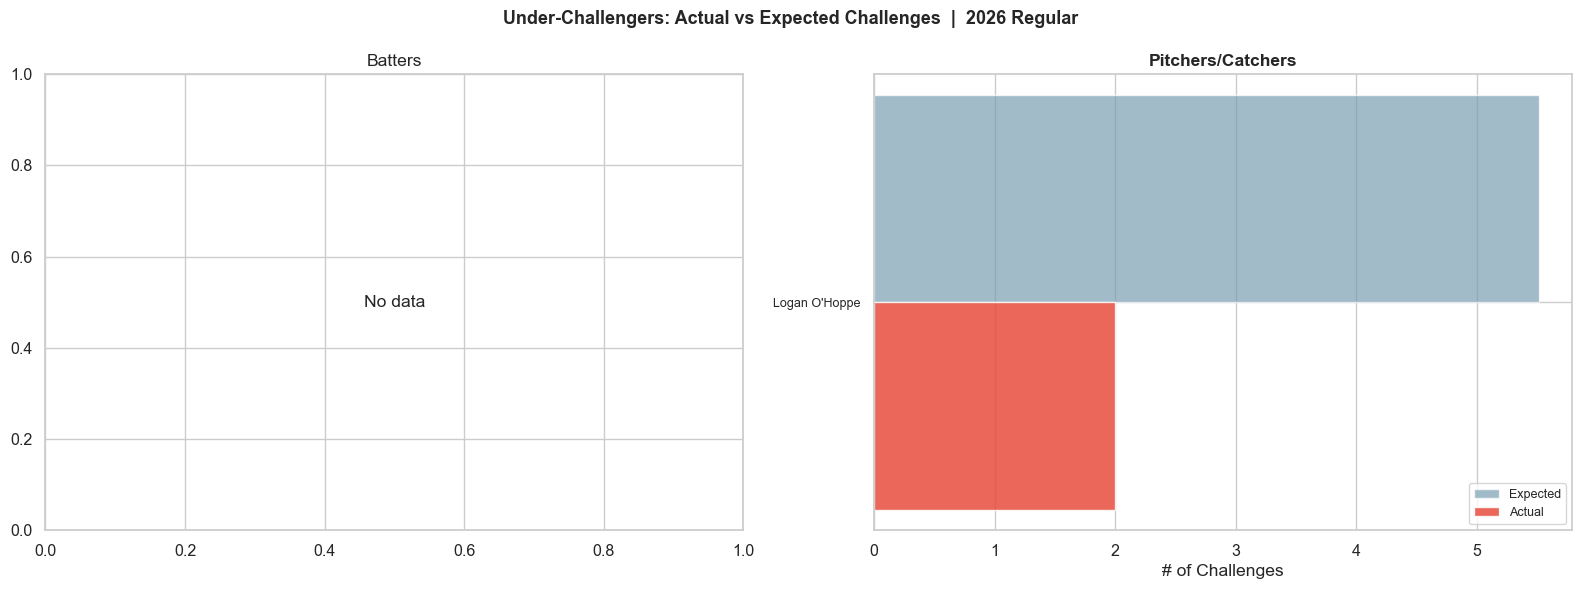

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Under-Challengers: Actual vs Expected Challenges  |  {YEAR} {GAME_TYPE.title()}',
    fontsize=13, fontweight='bold'
)

for ax, df, title, p_col in [
    (axes[0], underchal_bat.head(15), 'Batters', P_COL),
    (axes[1], underchal_pit.head(15), 'Pitchers/Catchers', P_COL_DEF),
]:
    if df.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue

    y = np.arange(len(df))
    ax.barh(y, df['expected_challenges'], 0.4, label='Expected', color=MLB_GRAY, alpha=0.7)
    ax.barh(y + 0.4, df['challenges'], 0.4, label='Actual', color=BAD_COLOR, alpha=0.85)

    ax.set_yticks(y + 0.2)
    ax.set_yticklabels(df[p_col], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('# of Challenges')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/abs_underchallengers.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Show as table with deficit column
show_cols = [c for c in [P_COL, T_COL, 'challenges', 'expected_challenges',
                          'challenge_deficit', 'pct_of_expected', 'overturn_rate'] if c in underchal_bat.columns]

fmt_u = {}
for c in show_cols:
    if 'rate' in c or 'pct' in c:
        fmt_u[c] = '{:.1%}'
    elif c in ('expected_challenges', 'challenge_deficit'):
        fmt_u[c] = '{:.1f}'

print('Top Under-Challenging Batters')
underchal_bat[show_cols].head(20).style.format(fmt_u).background_gradient(
    subset=['challenge_deficit'], cmap='Reds'
)

Top Under-Challenging Batters


,player_name,team_abbrev,challenges,expected_challenges,challenge_deficit,pct_of_expected,overturn_rate


## 9. Tracking Trends Over Time

Run this cell with expanding date ranges to watch how players and teams evolve as they get more reps with the system.

In [40]:
# ── Weekly snapshot: re-pull leaderboard for a rolling look ─────────────────
# Uncomment and adjust dates as the season progresses.

# snapshots = {
#     'Week 1': ('2026-03-26', '2026-04-01'),
#     'Week 2': ('2026-03-26', '2026-04-08'),
#     'Week 4': ('2026-03-26', '2026-04-22'),
# }
#
# records = []
# for label, (s, e) in snapshots.items():
#     _, cp = fetch_statcast_abs_pitches(s, e)
#     if not cp.empty:
#         ot = cp['is_overturn'].mean()
#         cr = len(cp) / len(statcast(start_dt=s, end_dt=e))
#         records.append({'period': label, 'overturn_rate': ot, 'challenge_rate': cr})
#
# trend_df = pd.DataFrame(records)
# trend_df.plot(x='period', y=['overturn_rate', 'challenge_rate'],
#               marker='o', figsize=(8, 4),
#               title='League-Wide ABS Trends Over First Month')
# plt.tight_layout()
# plt.show()

print('Uncomment the cells above and adjust dates to track trends over time.')

Uncomment the cells above and adjust dates to track trends over time.


## Summary

| Section | Key Metric | Source |
|---------|-----------|--------|
| Batter performance | Overturn rate, challenge rate | Savant ABS Leaderboard |
| Pitcher/catcher performance | Overturn rate, challenge rate | Savant ABS Leaderboard |
| Team leverage | Total Δ win expectancy | Savant ABS Leaderboard |
| Count tendencies | Challenges & overturn rate by count | Statcast pitch-level |
| Win value | Δ win expectancy per challenge outcome | Statcast + Leaderboard |
| Under-challengers | Actual vs model-expected challenges | Savant ABS Leaderboard |

**Data sources**
- [Baseball Savant ABS Dashboard](https://baseballsavant.mlb.com/abs)
- [Baseball Savant ABS Leaderboard](https://baseballsavant.mlb.com/leaderboard/abs-challenges)
- [Statcast Search CSV docs](https://baseballsavant.mlb.com/csv-docs)
- [pybaseball](https://github.com/jldbc/pybaseball)